# Exploratory Data Analysis (EDA)

This notebook focuses on analyzing hotel booking patterns, customer behavior, cancellation trends, and pricing dynamics.

The objective of this analysis is to uncover meaningful business insights that can support customer retention strategies and dynamic pricing decisions in the hospitality industry.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("../data/cleaned/cleaned_hotel_bookings.csv")

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.shape

(87396, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87396 entries, 0 to 87395
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87396 non-null  object 
 1   is_canceled                     87396 non-null  int64  
 2   lead_time                       87396 non-null  int64  
 3   arrival_date_year               87396 non-null  int64  
 4   arrival_date_month              87396 non-null  object 
 5   arrival_date_week_number        87396 non-null  int64  
 6   arrival_date_day_of_month       87396 non-null  int64  
 7   stays_in_weekend_nights         87396 non-null  int64  
 8   stays_in_week_nights            87396 non-null  int64  
 9   adults                          87396 non-null  int64  
 10  children                        87396 non-null  int64  
 11  babies                          87396 non-null  int64  
 12  meal                            

## Booking Cancellation Distribution

This analysis examines the proportion of canceled and non-canceled bookings to better understand customer cancellation behavior and overall booking stability.

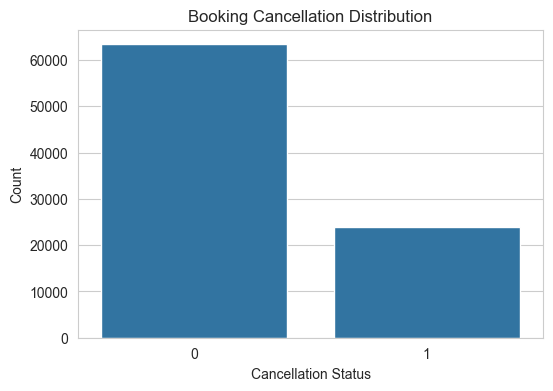

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='is_canceled', data=df)

plt.title('Booking Cancellation Distribution')
plt.xlabel('Cancellation Status')
plt.ylabel('Count')

plt.show()

### Observation

The dataset contains a significantly higher number of non-canceled bookings compared to canceled bookings.

This indicates that most customers complete their hotel reservations successfully, while a substantial portion still cancel bookings, making cancellation prediction an important business problem for the hospitality industry.

## Hotel Type Distribution

This analysis explores the distribution of bookings between Resort Hotels and City Hotels to understand customer accommodation preferences.

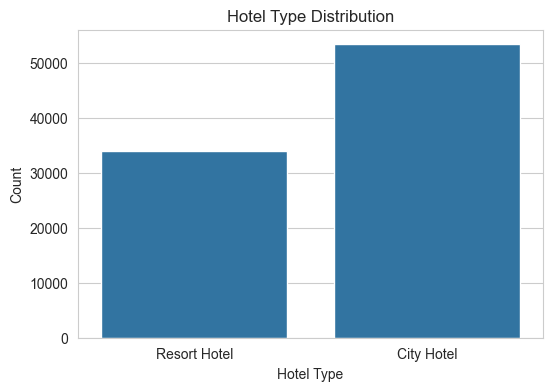

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='hotel', data=df)

plt.title('Hotel Type Distribution')
plt.xlabel('Hotel Type')
plt.ylabel('Count')

plt.show()

### Observation

City Hotels receive a higher number of bookings compared to Resort Hotels.

This suggests that urban hospitality demand is stronger in the dataset, potentially driven by business travel, short stays, and easier accessibility.

## Average Daily Rate (ADR) Distribution

This analysis examines the distribution of the Average Daily Rate (ADR) to understand hotel pricing behavior and identify potential pricing outliers.

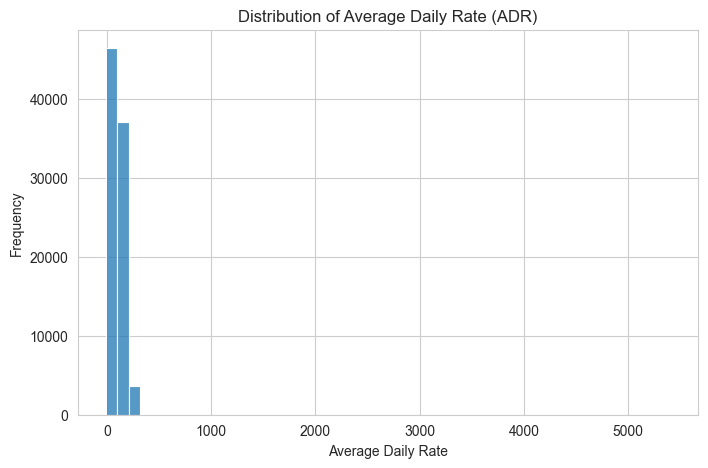

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['adr'], bins=50)

plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('Average Daily Rate')
plt.ylabel('Frequency')

plt.show()

### Observation

Most hotel bookings have relatively moderate ADR values concentrated within a lower price range.

The distribution is highly right-skewed, indicating the presence of extreme pricing outliers that may require further investigation during feature engineering and modeling.

## Booking Trends by Arrival Month

This analysis explores booking distribution across different months to identify seasonal demand patterns in the hospitality industry.

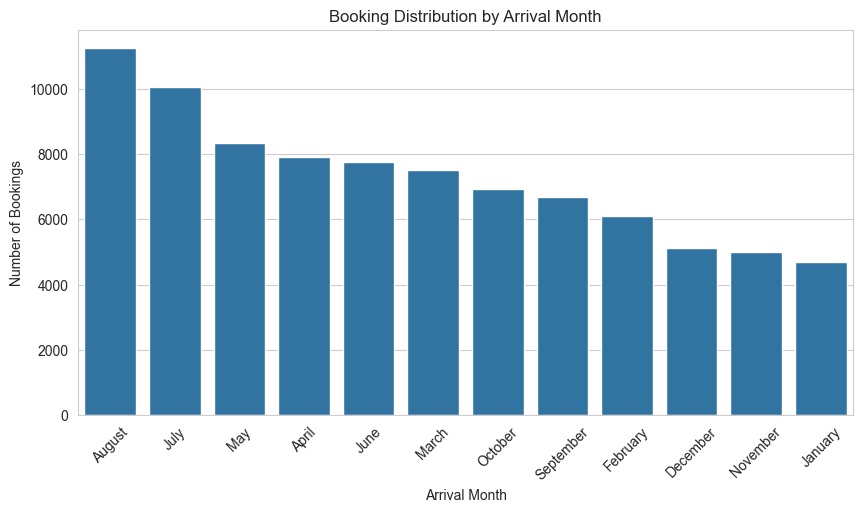

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(x='arrival_date_month', data=df,
              order=df['arrival_date_month'].value_counts().index)

plt.title('Booking Distribution by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Number of Bookings')

plt.xticks(rotation=45)

plt.show()

### Observation

Hotel bookings show clear seasonal variation across different months.

August and July record the highest number of bookings, indicating strong travel demand during peak holiday seasons, while January and November show comparatively lower booking activity.

## Cancellation Rate by Hotel Type

This analysis compares cancellation behavior between Resort Hotels and City Hotels to identify differences in customer booking patterns.

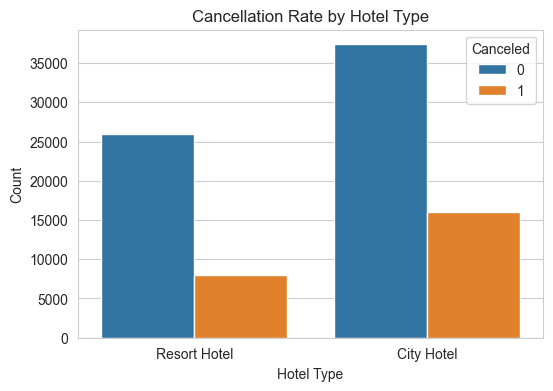

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x='hotel', hue='is_canceled', data=df)

plt.title('Cancellation Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count')

plt.legend(title='Canceled')

plt.show()

### Observation

City Hotels show a higher number of cancellations compared to Resort Hotels.

This may indicate that customers booking City Hotels are more likely to change travel plans, possibly due to business-related or short-term travel behavior.

## Lead Time Distribution

This analysis examines the distribution of booking lead time to understand how far in advance customers typically make hotel reservations.

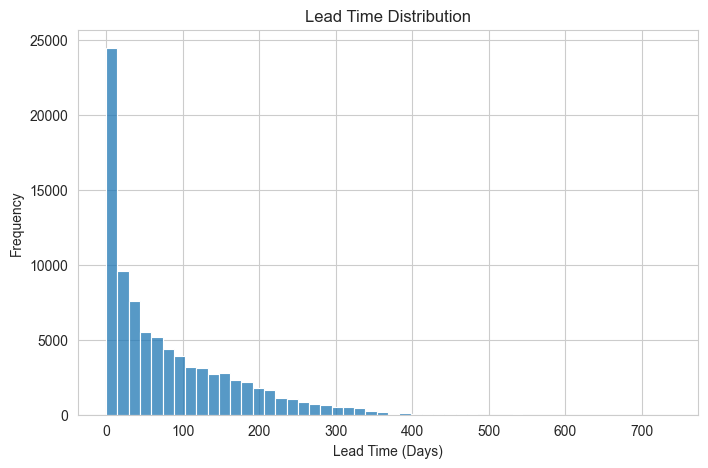

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['lead_time'], bins=50)

plt.title('Lead Time Distribution')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Frequency')

plt.show()

### Observation

Most customers make hotel bookings within a relatively shorter lead time period.

The distribution is highly right-skewed, showing that while many bookings are made close to the arrival date, a smaller number of customers book several months in advance.

## Average Daily Rate by Hotel Type

This analysis compares the Average Daily Rate (ADR) between Resort Hotels and City Hotels to understand pricing differences across hotel categories.

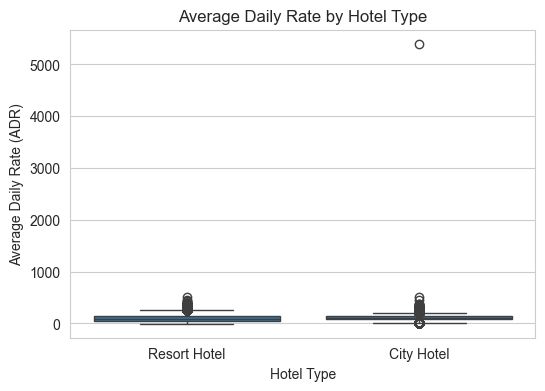

In [13]:
plt.figure(figsize=(6,4))

sns.boxplot(x='hotel', y='adr', data=df)

plt.title('Average Daily Rate by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Average Daily Rate (ADR)')

plt.show()

### Observation

City Hotels generally show slightly higher ADR values compared to Resort Hotels.

The visualization also reveals the presence of significant pricing outliers, particularly within City Hotels, indicating occasional premium or abnormal booking prices.

## Correlation Analysis

This analysis evaluates relationships between numerical variables to identify patterns, dependencies, and features that may influence booking cancellations and pricing behavior.

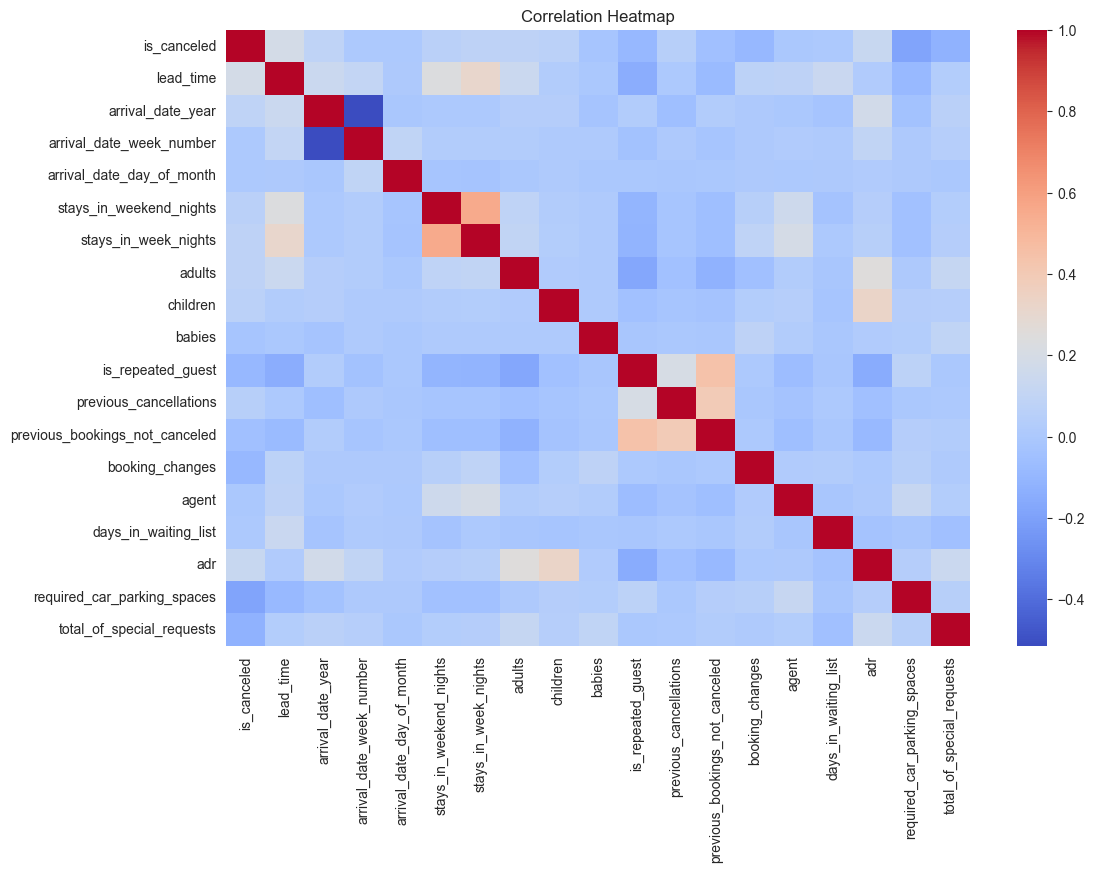

In [14]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

### Observation

Most numerical variables show weak to moderate correlations with each other, indicating relatively independent booking behaviors.

Notable positive relationships can be observed between:
- `stays_in_weekend_nights` and `stays_in_week_nights`
- `previous_cancellations` and `is_canceled`

Negative relationships are also visible between:
- `is_canceled` and `total_of_special_requests`

These patterns may provide useful signals during predictive modeling for booking cancellations.

## Customer Type Distribution

This analysis explores the distribution of different customer types to understand booking behavior across various customer segments.

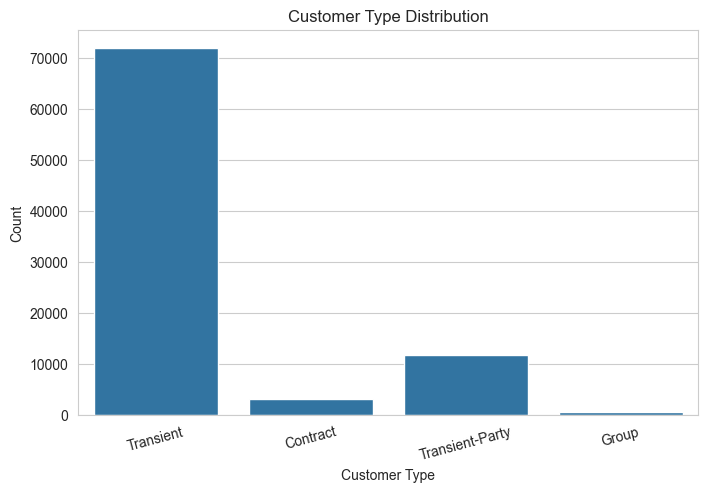

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(x='customer_type', data=df)

plt.title('Customer Type Distribution')
plt.xlabel('Customer Type')
plt.ylabel('Count')

plt.xticks(rotation=15)

plt.show()

### Observation

The majority of hotel bookings belong to the `Transient` customer category, indicating that most customers are individual short-term travelers.

`Transient-Party` customers also contribute a noticeable portion of bookings, while `Contract` and `Group` customers represent relatively smaller segments.

## Market Segment Distribution

This analysis examines different market segments to understand the primary sources of hotel bookings and customer acquisition channels.

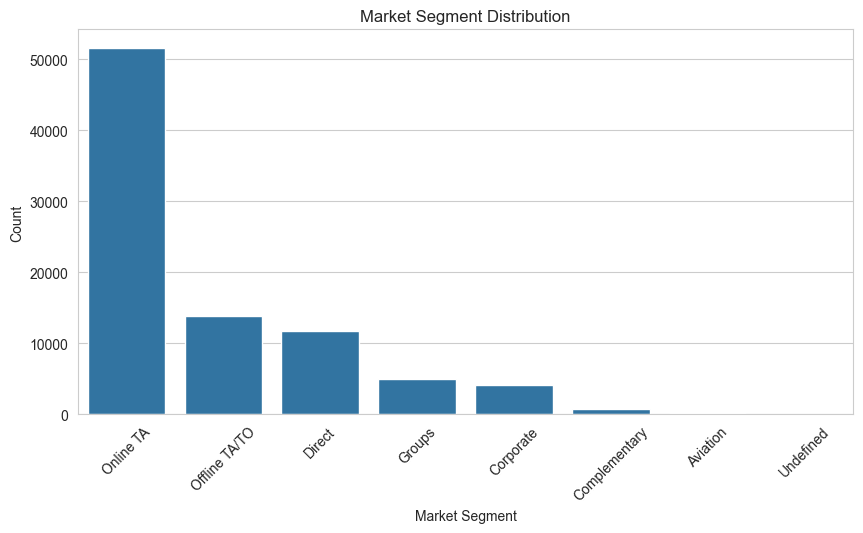

In [16]:
plt.figure(figsize=(10,5))

sns.countplot(x='market_segment', data=df,
              order=df['market_segment'].value_counts().index)

plt.title('Market Segment Distribution')
plt.xlabel('Market Segment')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

### Observation

The `Online TA` market segment contributes the highest number of hotel bookings by a large margin.

This indicates that online travel agencies play a dominant role in customer acquisition, while direct bookings and offline travel agents also contribute significantly to overall hotel demand.

## Conclusion

The exploratory data analysis revealed several important patterns within the hotel booking dataset.

Key findings include:
- A significant proportion of bookings are successfully completed, although cancellations remain substantial.
- City Hotels receive higher booking volumes and higher cancellation counts compared to Resort Hotels.
- Booking demand shows strong seasonal variation, with peak activity during July and August.
- Most customers belong to the `Transient` segment, indicating dominant short-term travel behavior.
- Online Travel Agencies are the primary booking source.
- ADR and lead time distributions contain noticeable outliers and right-skewed patterns.
- Correlation analysis identified useful relationships that may support predictive modeling for booking cancellations.

These insights provide a strong analytical foundation for feature engineering, machine learning modeling, and hospitality business intelligence dashboard development.